Index(['timestamp', 'holiday', 'tavg', 'tmin', 'tmax', 'prcp_x', 'snow',
       'wspd_x', 'wpgt_x', 'pres_x', 'temp', 'dwpt', 'rhum', 'prcp_y',
       'wspd_y', 'wpgt_y', 'pres_y', 'tsun', 'event_name', 'market_day',
       'special_friday', 'value'],
      dtype='object')
2266 567
(2097, 168, 1) (2097,)
(398, 168, 1) (398,)
1
Epoch 1/100


/Users/vroni/miniconda3/envs/ParkData/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


53/53 - 16s - 304ms/step - loss: 0.0573 - val_loss: 0.0360
Epoch 2/100
53/53 - 16s - 308ms/step - loss: 0.0248 - val_loss: 0.0307
Epoch 3/100
53/53 - 15s - 290ms/step - loss: 0.0209 - val_loss: 0.0264
Epoch 4/100
53/53 - 19s - 355ms/step - loss: 0.0173 - val_loss: 0.0218
Epoch 5/100
53/53 - 16s - 307ms/step - loss: 0.0150 - val_loss: 0.0172
Epoch 6/100
53/53 - 19s - 353ms/step - loss: 0.0118 - val_loss: 0.0132
Epoch 7/100
53/53 - 17s - 313ms/step - loss: 0.0094 - val_loss: 0.0096
Epoch 8/100
53/53 - 17s - 326ms/step - loss: 0.0076 - val_loss: 0.0075
Epoch 9/100
53/53 - 18s - 337ms/step - loss: 0.0061 - val_loss: 0.0063
Epoch 10/100
53/53 - 20s - 372ms/step - loss: 0.0053 - val_loss: 0.0058
Epoch 11/100
53/53 - 18s - 344ms/step - loss: 0.0050 - val_loss: 0.0051
Epoch 12/100
53/53 - 22s - 412ms/step - loss: 0.0046 - val_loss: 0.0050
Epoch 13/100
53/53 - 22s - 415ms/step - loss: 0.0042 - val_loss: 0.0048
Epoch 14/100
53/53 - 20s - 380ms/step - loss: 0.0041 - val_loss: 0.0047
Epoch 15/100


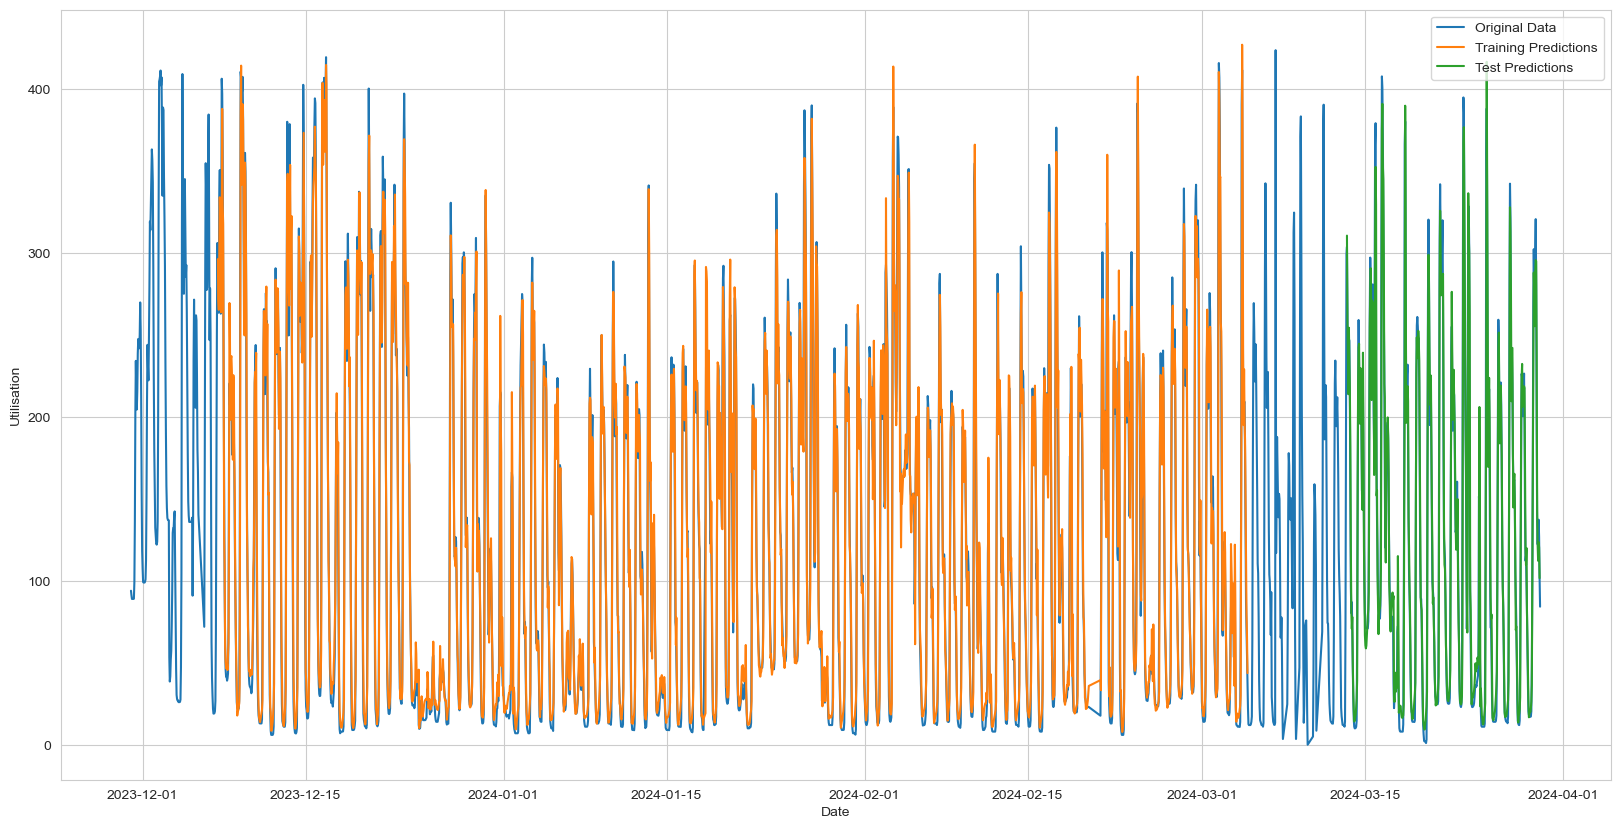

In [105]:
from pyexpat import features

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# convert an array of values into a dataset matrix
def create_dataset(dataset, window=168):
	dataX = []
	dataY = []
	for i in range(len(dataset)-window-1):
		dataX.append(dataset[i:(i+window), :])
		dataY.append(dataset[i + window, 0])
	return np.array(dataX), np.array(dataY)

tf.random.set_seed(7)
data = pd.read_csv('./data/out_hourly.csv')
dataset = pd.DataFrame(data)
dataset = dataset.sort_values('timestamp')
dataset['timestamp'] = pd.to_datetime(dataset['timestamp'])
print(df.columns)
start_date = pd.to_datetime('2023-11-30')
end_date = pd.to_datetime('2024-03-30')
dataset = dataset[(dataset['timestamp'] >= start_date) & (dataset['timestamp'] <= end_date)]
dataset['hour'] = df['timestamp'].dt.hour
dataset['dayOfWeek'] = df['timestamp'].dt.dayofweek
dataset.set_index('timestamp', inplace=True)
dates = dataset.index
dataset['event_name'] = dataset['event_name'].apply(lambda x: 1 if isinstance(x, str) and x != "0" else 0)
dataset['holiday'] = dataset['holiday'].apply(lambda x: 1 if pd.notna(x) and isinstance(x, str) and x.strip() != "" else 0)
columns_needed = ['rhum', 'tsun', 'value', 'event_name', 'holiday', 'hour', 'dayOfWeek']
dataset = dataset[[col for col in columns_needed if col in dataset.columns]]

#dataset = pd.DataFrame(df['value'], df['timestamp'])
#dataset = pd.DataFrame(df['value'])
#dataset_with_date.set_index('timestamp', inplace=True)

#dataset = np.array(dataset)
dataset = dataset['value'].astype('float32').values.reshape(-1, 1)
#LSTMs verwenden intern Aktivierungsfunktionen wie sigmoid und tanh:
#sigmoid: gibt Werte zwischen 0 und 1 aus
#tanh: gibt Werte zwischen -1 und 1 aus
#Diese großen Zahlen können die LSTM-Neuronen "überlasten" - sie arbeiten am besten mit kleinen Zahlen zwischen 0 und 1.
# normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

# split into train and test sets
train_size = int(len(dataset) * 0.80)
test_size = len(dataset) - train_size
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]
dates_train = dataset_with_date.iloc[0:train_size]
dates_test = dataset_with_date.iloc[train_size:]

# reshape into X=t and Y=t+1
print(len(train), len(test))
window = 168
trainX, trainY = create_dataset(train, window)
testX, testY = create_dataset(test, window)

print(trainX.shape, trainY.shape)
print(testX.shape, testY.shape)

# reshape input to be [samples, time steps, features]
#trainX = np.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
#testX = np.reshape(testX, (testX.shape[0], 1, testX.shape[1]))
# reshape input to be [samples, time steps, features]
#samples: Anzahl Trainingsbeispiele
#time steps: Länge der Zeitsequenz
#features: Anzahl Merkmale pro Zeitpunkt
#trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], trainX.shape[2]))
#testX = np.reshape(testX, (testX.shape[0], testX.shape[1], trainX.shape[2]))
print(trainX.shape[2])

# create and fit the LSTM network
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=(trainX.shape[1], trainX.shape[2])))
model.add(Dropout(0.2))
model.add(Dense(8, activation = 'relu'))
model.add(LSTM(128))
model.add(Dropout(0.2))
model.add(Dense(1, activation = 'linear'))
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(trainX, trainY, epochs=100, batch_size=32, verbose=2, validation_split=0.2)

# make predictions
trainPredict = model.predict(trainX)
trainPredict = np.clip(trainPredict, 0, 429)
testPredict = model.predict(testX)
testPredict = np.clip(testPredict, 0, 429)
# invert predictions
#invert the predictions before calculating error scores to ensure that performance is reported in the same units as the original data
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform([trainY])
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform([testY])
# calculate root mean squared error
trainScore = np.sqrt(mean_squared_error(trainY[0], trainPredict[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = np.sqrt(mean_squared_error(testY[0], testPredict[:,0]))
print('Test Score: %.2f RMSE' % (testScore))

rmse = np.sqrt(np.mean((testY[0] - testPredict[:,0])**2))
print(f'RMSE test: {rmse:.2f}')

#shift the predictions so that they align on the x-axis with the original dataset. Once prepared, the data is plotted, showing the original dataset in blue, the predictions for the training dataset in green, and the predictions on the unseen test dataset in red
# shift train predictions for plotting
#Nach der Vorhersage musst du zurück-transformieren:
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[window:len(trainPredict)+window, :] = trainPredict
# shift test predictions for plotting
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(trainPredict)+(window*2)+1:len(dataset)-1, :] = testPredict



# plot baseline and predictions
plt.figure(figsize=(20, 10))
dataset = scaler.inverse_transform(dataset)
plt.plot(dates, dataset, label='Original Data')
plt.plot(dates, trainPredictPlot, label='Training Predictions')
plt.plot(dates, testPredictPlot, label='Test Predictions')
plt.xlabel('Date')
plt.ylabel('Utilisation')
plt.legend()
plt.show()

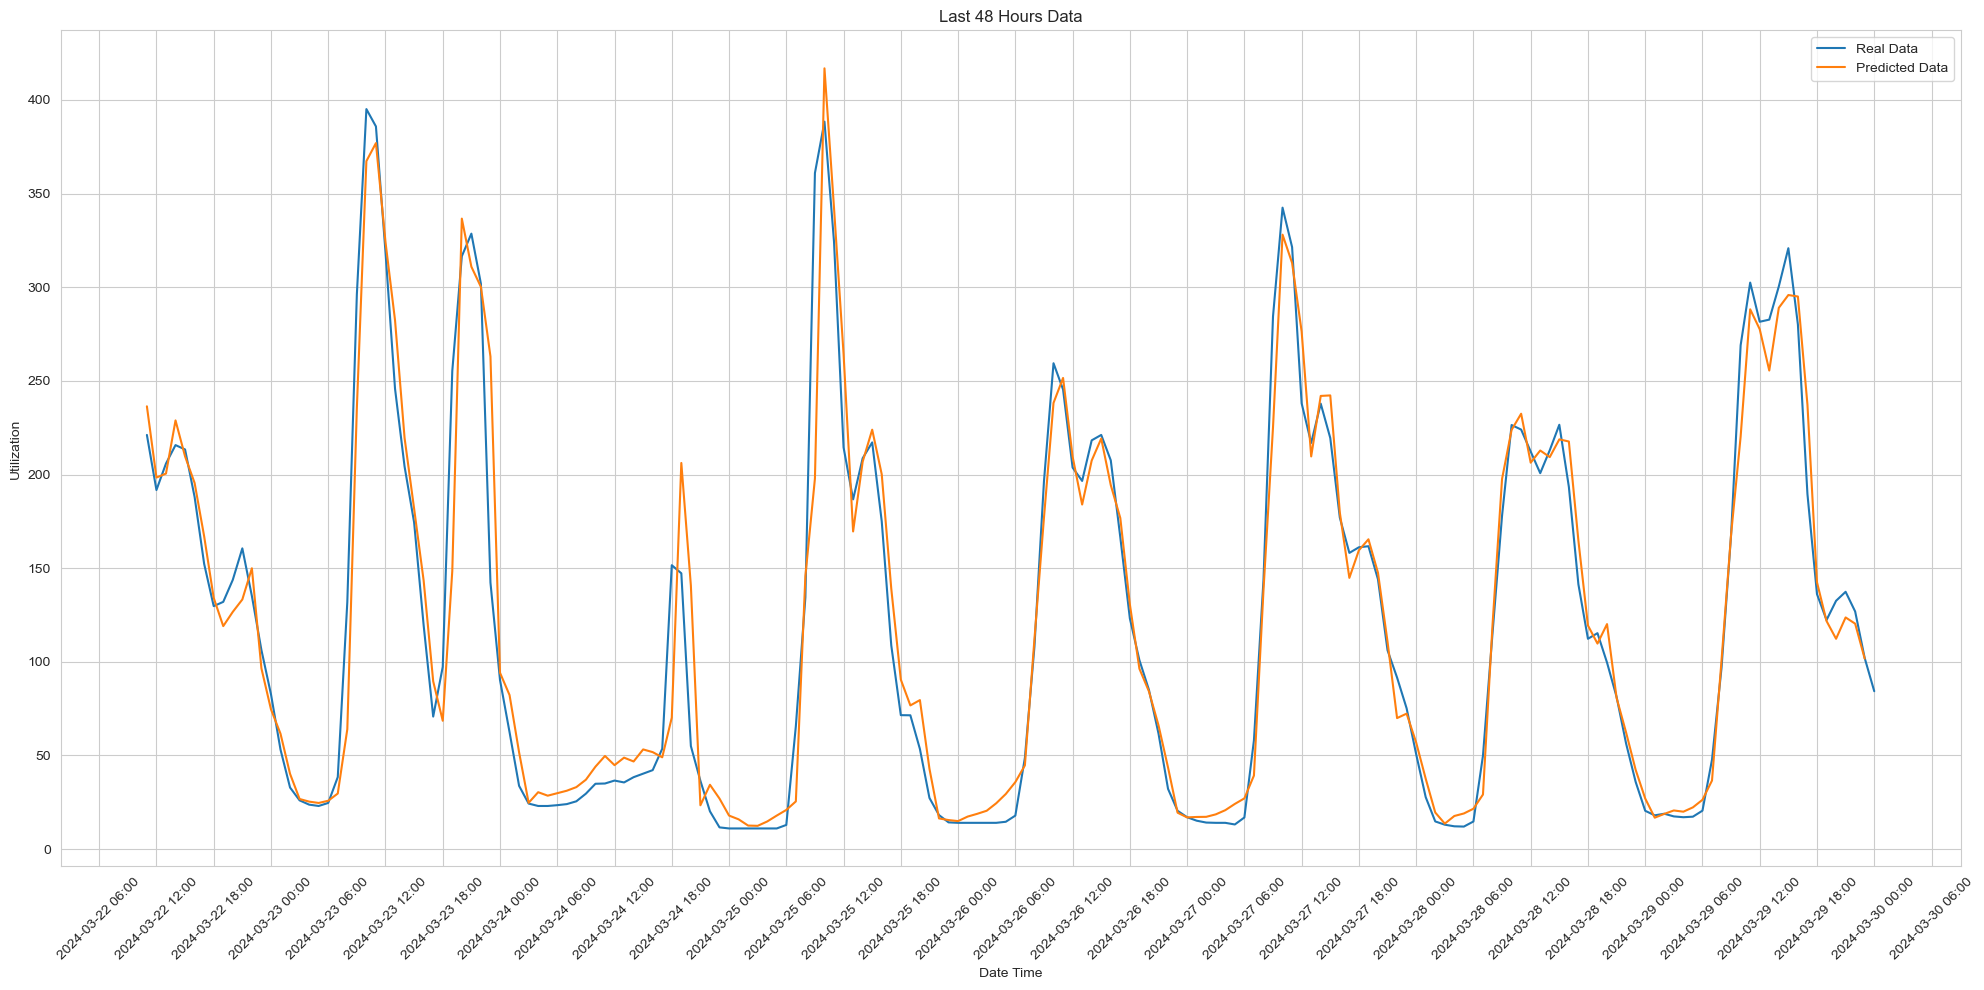

In [106]:
import matplotlib.dates as mdates
last_48 = testPredictPlot[-182:]
last_48 = np.clip(last_48, 0, 429)
last_48_dates = dates[-182:]
last_48_dataset = dataset[-182:]

plt.figure(figsize=(20, 10))
plt.plot(last_48_dates, last_48_dataset, label='Real Data')
plt.plot(last_48_dates, last_48, label='Predicted Data')
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
plt.xlabel('Date Time')
plt.ylabel('Utilization')
plt.title('Last 48 Hours Data')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

1729
